## Transfer Learning

Transfer learning is about taking the weights of another model and using them to train our custom model is called Transfer Learning

* Pre-trained model = foundations model

In [1]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.9.1
0.24.1


In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular import data_setup, engine

/opt/homebrew/Caskroom/miniconda/base/envs/nlp_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Now we have got the versions of torch and torchvision, we're after, let's import the code we have written in previous sections so that we do not have to write it all again

In [3]:
device = "mps" if torch.mps.is_available else "cpu"
device

'mps'

### 1. Get Data
to get our pizza, steak and sushi data to build a transfer learning model on

In [4]:
import os
import requests
import zipfile

from pathlib import Path

# Set up data path
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If image folder does not exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists, skipping re-downlaod...")
else:
    print(f"Did not find {image_path}, downloading it...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading zipfile...")
        f.write(request.content)


    # Unzip pizza, steak and sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak and sushi data...")
        zip_ref.extractall(image_path)

    # Remove .zip file 
    os.remove(data_path / "pizza_steak_sushi.zip")

data/pizza_steak_sushi directory exists, skipping re-downlaod...


In [5]:
# Set up directory path
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2. Create Datasets and DataLoader
No we've got some data, want to turn it into PyTorch DataLoaders.

To do so, we can use `data_setup.py` and the `create_dataloaders()` functions we made in 05. PyTorch Going Modular

There's one thing we have to think about when loading: how to **transform** it?

and there are two ways to do it:

1. Manually Created Transforms - you define what transforms you want for your data to go through

2. Automatically Created Transforms - the transforms for your data are defined by the model you'd like to use

Important point: when using a pretrained model, it is important that the data (including your custom data) that you pass through it is **transformed** in the same way that the data the model was trained on

In [6]:
from going_modular import data_setup

### 2.1 Creating a transform for `torchvision.models` (manual creation)
`torchvision.models` contains pretrained models (models ready for transfer learning)<br> right within `torchvision`
<br>

>All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224.

>The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

>You can use the following transform to normalize:

>normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

In [7]:
from torchvision import transforms
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize])

In [8]:
from going_modular import data_setup
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=manual_transforms,
                                                                               batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x169831f90>,
 ['pizza', 'steak', 'sushi'])

### 2.2 Creating a transform for `torchvision.models` (auto creation)

In [9]:
import torchvision

In [10]:
# Get a set of pre-trained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # "DEFAULT" = best available weights
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [11]:
# Get the transforms used to create our pre-trained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [12]:
# Create DataLoaders using automatic transforms
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transforms,
                                                                               batch_size=32)
train_dataloader, test_dataloader, class_names                                                                            

(<torch.utils.data.dataloader.DataLoader at 0x1698422d0>,
 ['pizza', 'steak', 'sushi'])

### 3. Getting a Pre-Trained model

There are various places to get a pretrained model, such as:

1. PyTorch domain libraries
2. Libraries like `timm` (torch image models)
3. HuggingFace Hub (plenty of different models)
4. Paperswithcode (for models across different problem spaces/domains)

### 3.1 Selecting the right model

The whole idea of transfer learning is to take an already well-performing model from a problem space similar to your own and then customize to your own problem

Three things to consider:
1. Speed - how fast does it run?
2. Size - how big is the model?
3. Performance - How well does it go on your chosen problem (e.g. how well does it classify food images? for FoodVision Mini)
4. Where does the model live? - On the device or on the server

### 3.2 Setting up a pre-trained model

Want to create an instance of a pre-trained EffNetB0

In [13]:
# Creating a pre-trained model
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights)

In [14]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [15]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

### 3.3 Getting info summary of the model using `torchinfo`

In [16]:
from torchinfo import summary

summary(model=model,
        input_size=[1, 3, 224, 224],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

### 3.4 Freezing the base model and changing the output shape according to our requirements

With a feature extractor model we freeze the base/foundation models and update the output layers to suit our own problems

In [17]:
# Freeze all the base layers
for params in model.features.parameters():
    params.requires_grad = False

In [18]:
from torchinfo import summary

summary(model=model,
        input_size=[1, 3, 224, 224],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 3.5 Changing the classifier layer

In [19]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

output_shape = len(class_names)

model.classifier = nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True).to(device)
)

In [20]:
from torchinfo import summary
summary(model=model,
        input_size=[1, 3, 224, 224],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 4. Train Model

In [21]:
# Defining loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
# Import train function
from going_modular import engine

# Set the manual seed
torch.manual_seed(42)
torch.mps.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       loss_fn=loss_fn,
                       optimizer=optimizer,
                       epochs=5,
                       device=device)

end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/nlp_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
 20%|██        | 1/5 [00:58<03:54, 58.63s/it]

Epoch: 1 | Train Loss: 1.081525444984436 | Train Acc: 0.40234375 | Test Loss: 0.8756584525108337 | Test Acc: 0.6903409090909092 | 


 40%|████      | 2/5 [01:56<02:54, 58.20s/it]

Epoch: 2 | Train Loss: 0.8526892364025116 | Train Acc: 0.796875 | Test Loss: 0.7429792682329813 | Test Acc: 0.8446969696969697 | 


 60%|██████    | 3/5 [02:54<01:56, 58.14s/it]

Epoch: 3 | Train Loss: 0.8144717067480087 | Train Acc: 0.7109375 | Test Loss: 0.6700516144434611 | Test Acc: 0.8759469696969697 | 


 80%|████████  | 4/5 [03:52<00:58, 58.09s/it]

Epoch: 4 | Train Loss: 0.6889330297708511 | Train Acc: 0.79296875 | Test Loss: 0.6314420302708944 | Test Acc: 0.8768939393939394 | 


100%|██████████| 5/5 [04:50<00:00, 58.11s/it]

Epoch: 5 | Train Loss: 0.6432408913969994 | Train Acc: 0.765625 | Test Loss: 0.5632256070772806 | Test Acc: 0.8759469696969697 | 
[INFO] Total training time: 290.602 seconds


### 5. Evaluate model by plotting loss curves

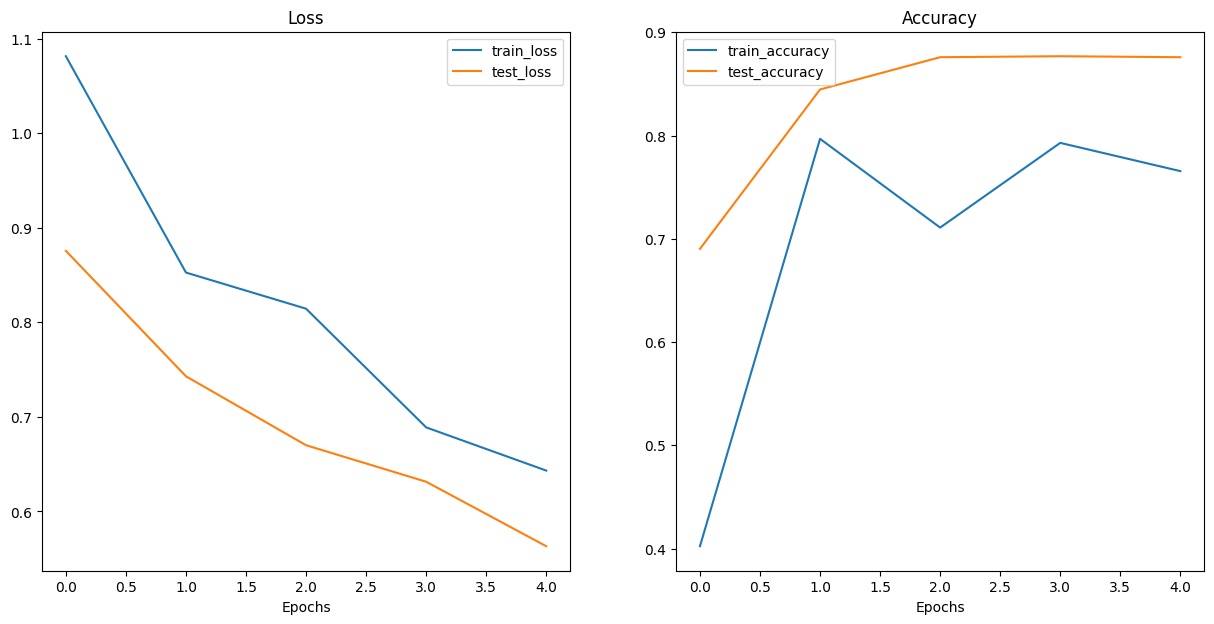

In [23]:
try:
    from helper_functions import plot_loss_curves
except:
    print(f"[INFO] Coudn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves

# Plot the loss curves of our model
plot_loss_curves(results)

### 5. Making a Prediction function

1. Take in a trained model, a list of class names, a filepath to a target image, an image size, a transform and a target device
2. Open the image with `PIL.Image.Open()`
3. Create a transform if one does not exist
4. Make sure the model is on the target device
5. Turn the model to `model.eval()` mode to make sure it is ready for inference (this will turn off things like `nn.Dropout()`)
6. Transform the target image and make sure its dimentionality is suited for the model (this mainly relates to batch size)
7. Make a prediction on the image by passing to the model
8. Convert the model's output logits to prediction probabilities using `torch.softmax()`
9. Convert the model's prediction probablities to prediction labels using `torch.argmax()`
10. Plot the image with `matplotlib` and set the title to the prediction label from step 9 and prediction probability from step 8

In [39]:
from typing import List, Tuple

from PIL import Image

# 1. Take in a trained model, class names, image path, image size, a transform and target device
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str, 
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    
    
    # 2. Open image
    img = Image.open(image_path)

    # 3. Create transformation for image (if one doesn't exist)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    ### Predict on image ### 

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
      # 6. Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
      transformed_image = image_transform(img).unsqueeze(dim=0)

      # 7. Make a prediction on image with an extra dimension and send it to the target device
      target_image_pred = model(transformed_image.to(device))

    # 8. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 9. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 10. Plot image with predicted label and probability 
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

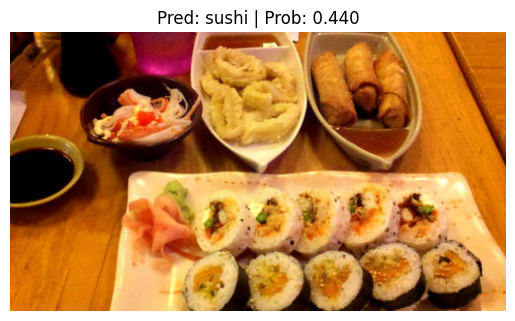

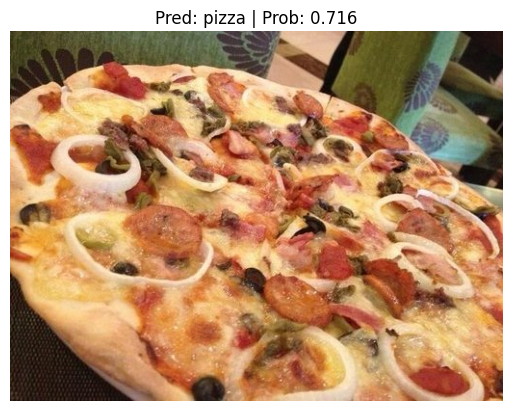

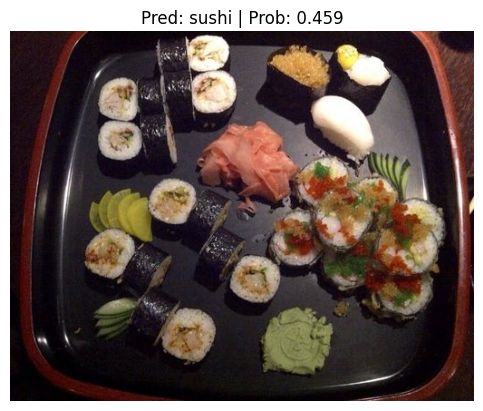

In [40]:
# Get a random list of image paths from test set
import random
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data 
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot_image(model=model, 
                        image_path=image_path,
                        class_names=class_names,
                        # transform=weights.transforms(), # optionally pass in a specified transform from our pretrained model weights
                        image_size=(224, 224))

### 6. Making Predictions on Custom Image

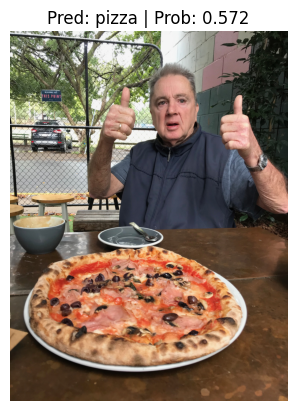

In [42]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

### 7. Extra Curriculum

### Q1. Make predictions on the entire test data

In [43]:
from tqdm.auto import tqdm

test_preds = []
model.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader):
        X, y = X.to(device), y.to(device)

        test_logits = model(X)

        pred_probs = torch.softmax(test_logits, dim=1)

        pred_labels = torch.argmax(pred_probs, dim=1)

        test_preds.append(pred_labels)

test_predictions = torch.cat(test_preds).cpu()
test_predictions

  0%|          | 0/3 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/nlp_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|██████████| 3/3 [00:20<00:00,  6.68s/it]


tensor([1, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 2, 2, 1, 0, 2, 1, 0, 1, 2, 2, 1, 0, 0,
        1, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
        0, 1, 0, 0, 1, 1, 0, 1, 0, 2, 0, 2, 2, 2, 2, 1, 2, 0, 2, 1, 0, 0, 2, 1,
        2, 0, 2])

In [44]:
test_truth = torch.cat([y for X, y in test_dataloader])
test_truth

/opt/homebrew/Caskroom/miniconda/base/envs/nlp_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


tensor([1, 0, 2, 2, 2, 2, 0, 1, 0, 0, 0, 2, 1, 2, 2, 2, 1, 0, 2, 2, 1, 0, 1, 1,
        1, 0, 0, 2, 2, 1, 0, 0, 2, 2, 0, 1, 2, 1, 2, 0, 1, 0, 2, 0, 2, 2, 2, 1,
        0, 2, 1, 0, 2, 2, 0, 2, 1, 2, 2, 0, 0, 2, 1, 1, 1, 2, 1, 2, 0, 0, 0, 2,
        0, 2, 0])

In [47]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


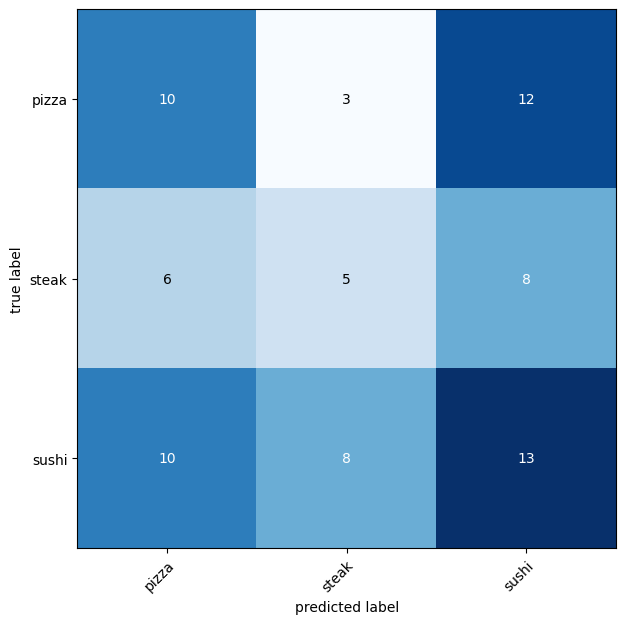

In [53]:
# Plotting a Confusion Matrix
import mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=test_predictions,
                         target=test_truth)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

### 2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images

In [ ]:
# Create a DataFrame with sample, label, prediciton probabilities and prediction labels

# Get all the test data paths
from pathlib import Path
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_labels = [path.parent.stem for path in test_data_paths]

# Create a function to return a list of dictionaries with sample, label and probs
def pred_and_store(test_paths, model):
    test_pred_list = []
    for path in test_paths:
        # Create empty dict to store info for each sample
        pred_dict = {}

        # Get sample path
        pred_dict["image_path"] = path

        # Get class names
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name

        # Get prediction
        from PIL import Image
        img = Image.open(path)
        transformed_image = transform(img).unsqueeze(dim=0)
        model.eval()
        with torch.inference_mode():
            pred_logit = model(transformed_image)
            pred_prob = torch.softmax(pred_logit, dim=1)
            pred_label = torch.argmax(pred_prob, dim=1)
            pred_class = class_names[pred_label]

            pred_dict["pred_prob"] = pred_prob
            pred_dict["pred_class"] = pred_class
        
        # Does the pred match true label?
        pred_dict["correct"] = class_names == pred_class

        # Add dictionary to the list of preds
        test_pred_list.append(pred_dict)
    
    return test_pred_list